## IMPORTS

In [54]:
import scipy.io
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## MAT TO CSV

### The "Ingestion" Pipeline Stage

**Extraction:** Reading the raw .mat file (using scipy.io or h5py).

**Transformation (The Conversion)**: * Unpacking the "complicated" nested structures.

Flattening multidimensional arrays into a 2D table.

Handling missing values (NaNs) that might have come from MATLAB.

**Loading:** Saving the cleaned data as a .csv (or often a .parquet file for better performance) to be used by the rest of the project.

In [55]:
filename = "1D_1.mat"

# so the keys are names of containers inside each part

def print_hdf5_structure(g, indent=0):
    for key in g.keys():
        item = g[key]
        print("  " * indent + key, type(item))
        if isinstance(item, h5py.Group):
            print_hdf5_structure(item, indent + 1)

with h5py.File(filename, "r") as f:
    print_hdf5_structure(f)

#refs# <class 'h5py._hl.group.Group'>
  0 <class 'h5py._hl.dataset.Dataset'>
  1 <class 'h5py._hl.dataset.Dataset'>
  2 <class 'h5py._hl.dataset.Dataset'>
  3 <class 'h5py._hl.dataset.Dataset'>
  4 <class 'h5py._hl.dataset.Dataset'>
  5 <class 'h5py._hl.dataset.Dataset'>
  6 <class 'h5py._hl.group.Group'>
    behavior <class 'h5py._hl.group.Group'>
      chamber <class 'h5py._hl.dataset.Dataset'>
      duration <class 'h5py._hl.dataset.Dataset'>
      eye_tracked <class 'h5py._hl.dataset.Dataset'>
      flag_old_app <class 'h5py._hl.dataset.Dataset'>
      flag_recal <class 'h5py._hl.dataset.Dataset'>
      lick <class 'h5py._hl.group.Group'>
        FPS <class 'h5py._hl.dataset.Dataset'>
        bout_tag_list <class 'h5py._hl.dataset.Dataset'>
        chamber <class 'h5py._hl.dataset.Dataset'>
        duration <class 'h5py._hl.dataset.Dataset'>
        interp <class 'h5py._hl.dataset.Dataset'>
        lick_tag_list <class 'h5py._hl.dataset.Dataset'>
        mat_data_file <class 'h5py.

In [56]:
with h5py.File(filename, "r") as f:

    data = {}

    grp = f["data_recordings"]

    for key in grp.keys():
        data[key] = grp[key][()]   # load numpy array

for k,v in data.items():
    print(k, np.shape(v))

Neural_Data (3, 1)
Neural_Prop (3, 1)
eye (3, 1)
id (3, 1)
meta_data (3, 1)
tongue (3, 1)


At this point, we are only inspecting the top-level groups and their shapes inside `data_recordings`. The `(3, 1)` shapes indicate MATLAB cell containers, which means the actual signal arrays are still stored behind references and must be dereferenced next.

The shapes (3, 1) tell us something important about your .mat file:
These are MATLAB cell arrays, not the actual data.
In HDF5 .mat files, MATLAB cell arrays are stored as arrays of object references pointing into #refs#.
So what you're currently loading are references, not the real data.

In [57]:
def dereference_cell(dataset, f):

    refs = dataset[()]
    out = []

    for r in refs.flatten():
        if isinstance(r, h5py.Reference):
            out.append(np.array(f[r]))
        else:
            out.append(r)

    return out

In [58]:
data = {}

with h5py.File(filename, "r") as f:

    grp = f["data_recordings"]

    for key in grp.keys():
        data[key] = dereference_cell(grp[key], f)

for k,v in data.items():
    print(k, len(v))

Neural_Data 3
Neural_Prop 3
eye 3
id 3
meta_data 3
tongue 3


In [59]:
for i in range(3):
    print(f"\nRecording {i}")
    print("Neural_Data:", data["Neural_Data"][i].shape)
    print("eye:", data["eye"][i].shape)
    print("tongue:", data["tongue"][i].shape)


Recording 0
Neural_Data: (2,)
eye: (3,)
tongue: (15,)

Recording 1
Neural_Data: (2,)
eye: (3,)
tongue: (15,)

Recording 2
Neural_Data: (2,)
eye: (3,)
tongue: (15,)


Here we validate that each recording has expected arrays for `Neural_Data`, `eye`, and `tongue`. This confirms that reference resolution worked and gives a quick sanity check before deeper parsing of nested elements.

In [60]:
for i, item in enumerate(data["Neural_Data"][0]):
    print(i, type(item), getattr(item, "shape", None))

0 <class 'numpy.str_'> ()
1 <class 'numpy.str_'> ()


In [61]:
for i, item in enumerate(data["eye"][0]):
    print(i, type(item), getattr(item, "shape", None))

0 <class 'numpy.str_'> ()
1 <class 'numpy.str_'> ()
2 <class 'numpy.str_'> ()


In [62]:
for i, item in enumerate(data["tongue"][0]):
    print(i, type(item), getattr(item, "shape", None))

0 <class 'numpy.str_'> ()
1 <class 'numpy.str_'> ()
2 <class 'numpy.str_'> ()
3 <class 'numpy.str_'> ()
4 <class 'numpy.str_'> ()
5 <class 'numpy.str_'> ()
6 <class 'numpy.str_'> ()
7 <class 'numpy.str_'> ()
8 <class 'numpy.str_'> ()
9 <class 'numpy.str_'> ()
10 <class 'numpy.str_'> ()
11 <class 'numpy.str_'> ()
12 <class 'numpy.str_'> ()
13 <class 'numpy.str_'> ()
14 <class 'numpy.str_'> ()


In [63]:
def resolve_reference_strings(arr, f):

    out = []

    for ref in arr:

        if isinstance(ref, (np.str_, str)):
            out.append(np.array(f[ref]))
        else:
            out.append(ref)

    return out

In [64]:
data = {}

with h5py.File(filename, "r") as f:

    grp = f["data_recordings"]

    for key in grp.keys():

        cell = grp[key][()]   # MATLAB cell array
        resolved = []

        for ref in cell.flatten():

            if isinstance(ref, h5py.Reference):
                resolved.append(np.array(f[ref]))

        data[key] = resolved

This block rebuilds `data` by dereferencing every MATLAB cell entry into concrete NumPy arrays. After this step, each key in `data_recordings` should map to a Python list of resolved recording-level arrays.

In [65]:
for i in range(len(data["Neural_Data"])):
    print(i, data["Neural_Data"][i].shape)

0 (2,)
1 (2,)
2 (2,)


These are containers again

In [66]:
for i, item in enumerate(data["Neural_Data"][0]):
    print(i, type(item))
    print(item)

0 <class 'numpy.str_'>
CS_time
1 <class 'numpy.str_'>
SS_time


In [67]:
with h5py.File(filename, "r") as f:
    print(list(f["#refs#"].keys())[:10])

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [68]:
with h5py.File(filename, "r") as f:
    unit = f["#refs#/b"]
    print(list(unit.keys()))

['CS_time', 'SS_time']


In [69]:
dataset = []

with h5py.File(filename, "r") as f:

    refs = f["data_recordings"]["Neural_Data"][()]

    for ref in refs.flatten():

        unit = f[ref]

        cs = unit["CS_time"][()]
        ss = unit["SS_time"][()]

        dataset.append({
            "CS_time": cs,
            "SS_time": ss
        })

print(len(dataset))

3


This is the main extraction step for neural spike timings. For each recording reference, we read `CS_time` and `SS_time` and store them in a clean list-of-dictionaries format (`dataset`) for easier downstream conversion and analysis.

3 Neural Recordings

In [70]:
for i, rec in enumerate(dataset):
    print(f"\nRecording {i}")
    print("CS_time head:", rec["CS_time"][:10])
    print("SS_time head:", rec["SS_time"][:10])


Recording 0
CS_time head: [[7404.118 7407.433 7408.867 ... 9446.181 9449.656 9450.258]]
SS_time head: [[7404.117 7404.117 7404.117 ... 9453.104 9453.111 9453.123]]

Recording 1
CS_time head: [[ 9463.704  9465.285  9465.978 ... 11531.509 11531.989 11532.436]]
SS_time head: [[ 9463.704  9463.704  9463.704 ... 11534.586 11534.595 11534.6  ]]

Recording 2
CS_time head: [[11546.415 11547.753 11548.695 ... 13536.121 13538.16  13538.738]]
SS_time head: [[11546.355 11546.355 11546.355 ... 13539.903 13539.903 13539.903]]


In [71]:
for rec in dataset:
    rec["CS_time"] = rec["CS_time"].squeeze()
    rec["SS_time"] = rec["SS_time"].squeeze()

In [72]:
for i, rec in enumerate(dataset):

    df = pd.DataFrame({
        "CS_time": pd.Series(rec["CS_time"]),
        "SS_time": pd.Series(rec["SS_time"])
    })

    print(f"\nRecording {i}")
    print(df.head())


Recording 0
    CS_time   SS_time
0  7404.118  7404.117
1  7407.433  7404.117
2  7408.867  7404.117
3  7409.068  7404.117
4  7411.087  7404.117

Recording 1
    CS_time   SS_time
0  9463.704  9463.704
1  9465.285  9463.704
2  9465.978  9463.704
3  9468.189  9463.704
4  9468.374  9463.704

Recording 2
     CS_time    SS_time
0  11546.415  11546.355
1  11547.753  11546.355
2  11548.695  11546.355
3  11549.310  11546.355
4  11550.565  11546.355


After squeezing dimensions, each recording is converted to a pandas DataFrame with aligned `CS_time` and `SS_time` columns. This is the final tabular view before writing data to CSV files if needed.

In [73]:
print("dataset type:", type(dataset))
print("number of recordings:", len(dataset))

for i, rec in enumerate(dataset):
    print(f"\nRecording {i}")
    print("record type:", type(rec))
    print("keys:", list(rec.keys()))
    for key, value in rec.items():
        arr = np.asarray(value)
        print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

dataset type: <class 'list'>
number of recordings: 3

Recording 0
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1218,), dtype=float64
  SS_time: shape=(316206,), dtype=float64

Recording 1
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1308,), dtype=float64
  SS_time: shape=(315023,), dtype=float64

Recording 2
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1150,), dtype=float64
  SS_time: shape=(296069,), dtype=float64


## 1D_1 File Structure and Conversion Pipeline

This is the structure for **`1D_1` only**, from raw source file to DataFrame-ready CSV.

---

### Pipeline View (Raw → DataFrame)

```text
1D_1.mat
   │
   ├─ load .mat content (h5py)
   │
   ├─ extract required arrays/keys from MATLAB structure
   │
   ├─ shape/flatten/align values as columns
   │
   ├─ build pandas DataFrame
   │
   ├─ save CSV
   ▼
aligned_spikes_1D1.csv
   │
   └─ read with pandas (pd.read_csv) as DataFrame for analysis
```

## Integrity Checks

In [74]:
def run_level1_audit(dataset_list):
    audit_results = []

    for i, session in enumerate(dataset_list):
        # calculate basic health metrics
        ss_count = len(session['SS_time'])
        cs_count = len(session['CS_time'])

        # Check for "Time Jumps" (should be 0)
        time_glitches = np.sum(np.diff(session['SS_time']) <= 0)

        audit_results.append({
            "Session": i + 1,
            "SS_Spikes": ss_count,
            "CS_Spikes": cs_count,
            "Duration (s)": np.round(session['SS_time'][-1], 2) if ss_count > 0 else 0,
            "Healthy_Timestamps": "Yes" if time_glitches == 0 else "CORRUPT"
        })

    return pd.DataFrame(audit_results)

# Run it!
audit_df = run_level1_audit(dataset)
print(audit_df)

   Session  SS_Spikes  CS_Spikes  Duration (s) Healthy_Timestamps
0        1     316206       1218       9453.12            CORRUPT
1        2     315023       1308      11534.60            CORRUPT
2        3     296069       1150      13539.90            CORRUPT


In [75]:
times = dataset[0]['SS_time'].flatten()
glitches = np.where(np.diff(times) <= 0)[0]

print(f"Number of timing glitches: {len(glitches)}")
if len(glitches) > 0:
    idx = glitches[0]
    print(f"First glitch at index {idx}:")
    print(f"Time at {idx}: {times[idx]}")
    print(f"Time at {idx+1}: {times[idx+1]}")

Number of timing glitches: 9469
First glitch at index 0:
Time at 0: 7404.117
Time at 1: 7404.117


In [76]:
times = dataset[0]['SS_time'].flatten()
backwards_jumps = np.where(np.diff(times) < 0)[0]  # Note the "less than" symbol

if len(backwards_jumps) > 0:
    print(f"\u26a8\ufe0f ALERT: Time jumps BACKWARDS {len(backwards_jumps)} times.")
    print(f"Jump at index {backwards_jumps[0]}: {times[backwards_jumps[0]]} -> {times[backwards_jumps[0]+1]}")
else:
    print("\u2705 No backward jumps. It's likely just duplicates or zero-width intervals.")

✅ No backward jumps. It's likely just duplicates or zero-width intervals.


In [77]:
for session in dataset:
    session['SS_time'] = np.unique(session['SS_time'])
    session['CS_time'] = np.unique(session['CS_time'])
print("Cleaning complete: Duplicates removed.")

Cleaning complete: Duplicates removed.


In [78]:
audit_df_after = run_level1_audit(dataset)
print("--- AUDIT: AFTER CLEANING ---")
print(audit_df_after)

--- AUDIT: AFTER CLEANING ---
   Session  SS_Spikes  CS_Spikes  Duration (s) Healthy_Timestamps
0        1     306737       1218       9453.12                Yes
1        2     305957       1308      11534.60                Yes
2        3     287653       1149      13539.90                Yes


## Visualisations

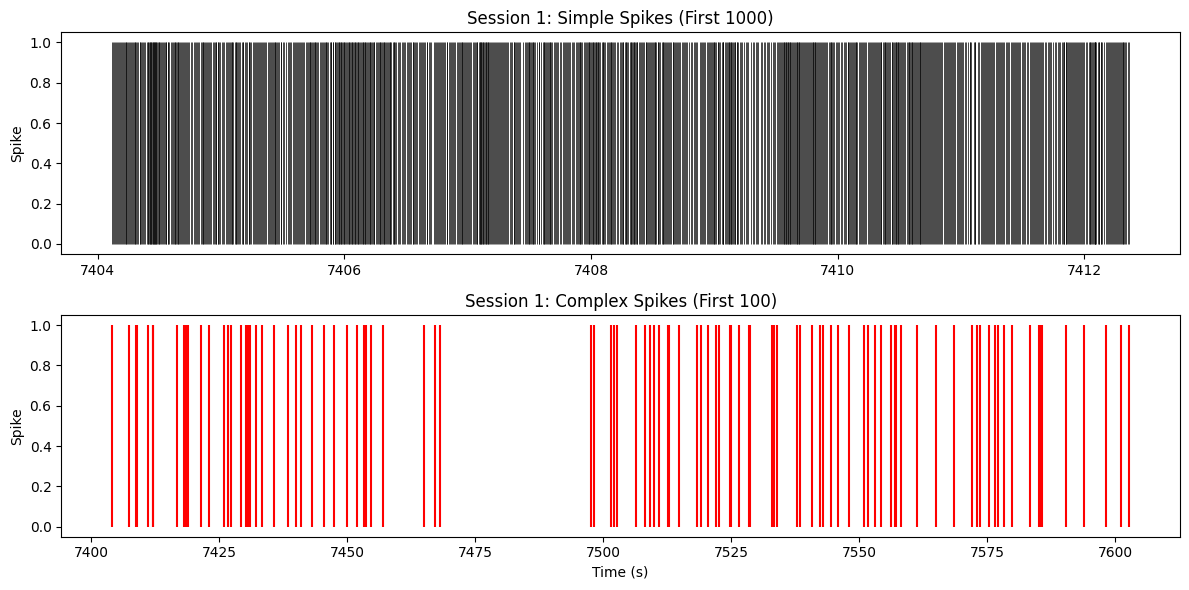

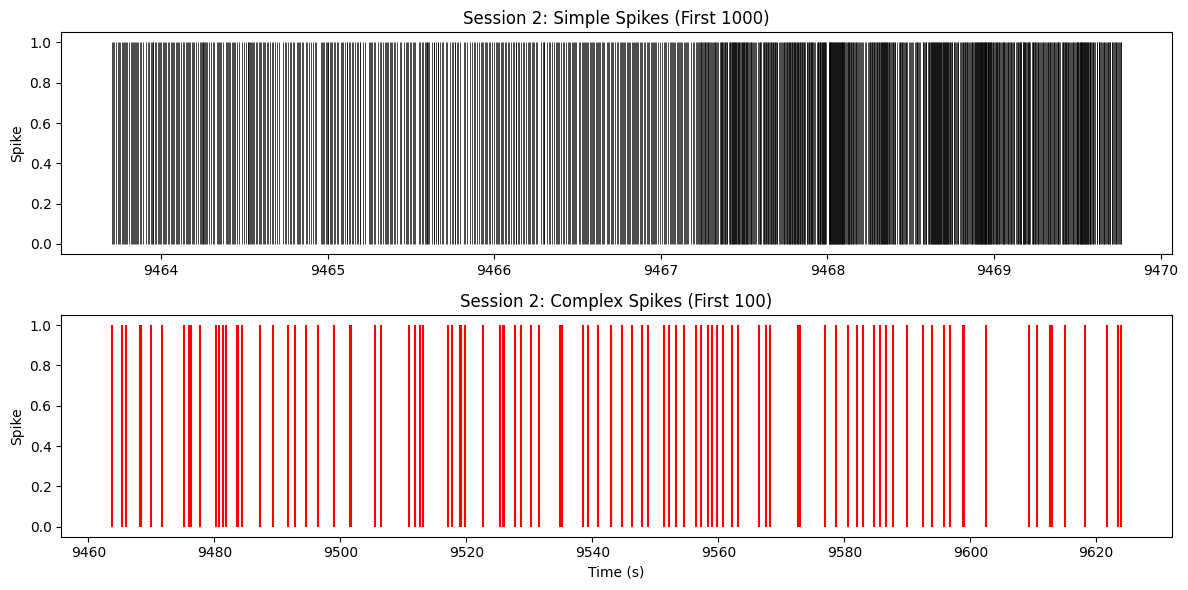

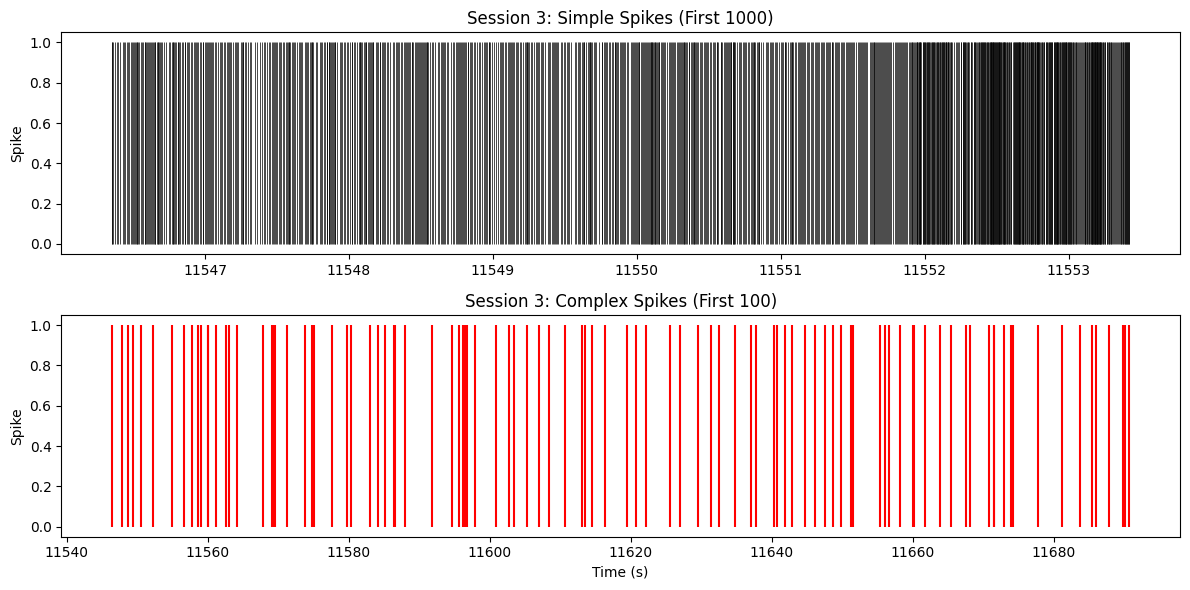

In [79]:
def plot_session(session_idx):
    session = dataset[session_idx]

    plt.figure(figsize=(12, 6))

    # Simple Spikes (SS)
    plt.subplot(2, 1, 1)
    plt.vlines(session['SS_time'][:1000], 0, 1, color='black', linewidth=0.5)
    plt.title(f"Session {session_idx+1}: Simple Spikes (First 1000)")
    plt.ylabel("Spike")

    # Complex Spikes (CS)
    plt.subplot(2, 1, 2)
    plt.vlines(session['CS_time'][:100], 0, 1, color='red', linewidth=1.5)
    plt.title(f"Session {session_idx+1}: Complex Spikes (First 100)")
    plt.xlabel("Time (s)")
    plt.ylabel("Spike")

    plt.tight_layout()
    plt.show()

plot_session(0)
plot_session(1)
plot_session(2)

## ALIGNMENT

### Deceleration Strength Feature (Δv / Δt)

The dataset does not provide continuous tongue kinematics (i.e., full velocity time-series), so true deceleration (acceleration = dV/dt) cannot be computed directly.

Instead, we construct an **approximate deceleration measure** using available event-based features:

- `tongue_vm_max`: maximum velocity during protraction  
- `tongue_vm_min`: minimum velocity (typically during slowing/retraction)  
- `time_vmax`: time of peak velocity  
- `time_vmin`: time of minimum velocity  

### Definition

We define **deceleration strength** as:

$$\text{Deceleration Strength} = \frac{\Delta v}{\Delta t} = \frac{v_{max}}{t_{vmin} - t_{vmax}}$$

### Why this matters

According to the paper, cerebellar Purkinje cells are strongly involved in controlling the **deceleration phase of tongue movement**, particularly as the tongue approaches its target. This feature provides a biologically meaningful proxy for that control signal.

# 1D_1.mat — Lick Alignment

In [80]:
filename = "1D_1.mat"

with h5py.File(filename, "r") as f:

    tongue_ref_raw = f['data_recordings']['tongue'][()]

    if isinstance(tongue_ref_raw, np.ndarray):
        tongue_ref = tongue_ref_raw.flatten()[0]
    else:
        tongue_ref = tongue_ref_raw

    lick_group = f[tongue_ref]
    print(f"Successfully accessed lick data in group: {lick_group.name}")

    all_tags = lick_group['tag_lick'][()].flatten()
    all_onsets = lick_group['time_onset'][()].flatten()

print(f"Total licks found: {len(all_tags)}")
print(f"Unique Label IDs: {np.unique(all_tags)}")

# counting
unique, counts = np.unique(all_tags, return_counts=True)
print("Label Counts:", dict(zip(unique, counts)))

Successfully accessed lick data in group: /#refs#/Ab
Total licks found: 2547
Unique Label IDs: [1. 2. 3. 4. 5. 6. 7.]
Label Counts: {np.float64(1.0): np.int64(282), np.float64(2.0): np.int64(209), np.float64(3.0): np.int64(80), np.float64(4.0): np.int64(8), np.float64(5.0): np.int64(540), np.float64(6.0): np.int64(95), np.float64(7.0): np.int64(1333)}


In [81]:
WINDOW_PRE = 0.100  # tells the code to only look at the 100 milliseconds immediately before the tongue moves. This captures the brain's "planning" phase.
aligned_dataset_1D1 = []

with h5py.File(filename, "r") as f:
    tongue_ref = f['data_recordings']['tongue'][0, 0]
    lick_group = f[tongue_ref]

    raw_lick_tags = lick_group['tag_lick'][()].flatten()
    all_onsets = lick_group['time_onset'][()].flatten()
    raw_bout_tags = lick_group['tag_bout'][()].flatten()
    harvest_tags = lick_group['tag_harvest'][()].flatten()
    velocities = lick_group['tongue_vm_max'][()].flatten()
    decelerations = lick_group['tongue_vm_min'][()].flatten()

    time_vmax = lick_group['time_vmax'][()].flatten()
    time_vmin = lick_group['time_vmin'][()].flatten()

    all_tags = []
    for i in range(len(raw_lick_tags)):
        if raw_bout_tags[i] == 0:
            all_tags.append(0)  # 0 = Grooming
        else:
            all_tags.append(int(raw_lick_tags[i]))

    neural_refs = f["data_recordings"]["Neural_Data"][()].flatten()

    print(f"Aligning {len(all_onsets)} licks across {len(neural_refs)} electrodes...")

    # Alignment Loop
    # Goes through every single lick one by one.
    # Finds the exact timestamp of the lick (t_onset) and calculates the start and end of the 100ms window.
    for i in range(len(all_onsets)):
        t_onset = all_onsets[i]
        label = int(all_tags[i])

        t_start = t_onset - WINDOW_PRE
        t_end = t_onset

        lick_spikes = []

        # Extract spikes from every electrode for this specific 100ms window
        for ref in neural_refs:
            ss_spikes = f[ref]['SS_time'][()]
            cs_spikes = f[ref]['CS_time'][()]

            # SS spikes in window
            ss_mask = (ss_spikes >= t_start) & (ss_spikes < t_end)
            ss_rel = ss_spikes[ss_mask] - t_end

            # CS spikes in window
            cs_mask = (cs_spikes >= t_start) & (cs_spikes < t_end)
            cs_rel = cs_spikes[cs_mask] - t_end

            lick_spikes.append({
                "SS": ss_rel,
                "CS": cs_rel
            })

        delta_v = velocities[i]
        delta_t = time_vmin[i] - time_vmax[i]

        if delta_t > 0:
            decel_strength = delta_v / delta_t
        else:
            decel_strength = np.nan  # avoid divide-by-zero

        # storing lick
        aligned_dataset_1D1.append({
            'lick_id': i,
            'final_label': label,
            'spike_times': lick_spikes,
            'raw_bout_tag': raw_bout_tags[i],
            'harvest_tag': harvest_tags[i],
            'velocity_max': velocities[i],
            'deceleration_min': decelerations[i],
            'decel_strength': decel_strength,
        })

print(f"Successfully aligned {len(aligned_dataset_1D1)} packets.")

Aligning 2547 licks across 3 electrodes...
Successfully aligned 2547 packets.


In [82]:
# Picking a sample lick from the aligned dataset to inspect
sample_idx = 10
sample_lick = aligned_dataset_1D1[sample_idx]

print(f"--- Diagnostic for Lick Index: {sample_idx} ---")
print(f"Lick Label (Numeric ID): {sample_lick['final_label']}")
print(f"Number of Electrodes Checked: {len(sample_lick['spike_times'])}")

# Check if any spikes were actually found
total_ss = sum([len(s['SS']) for s in sample_lick['spike_times']])
total_cs = sum([len(s['CS']) for s in sample_lick['spike_times']])
print(f"Total SS spikes found in 100ms window: {total_ss}")
print(f"Total CS spikes found in 100ms window: {total_cs}")

# Look at the raw relative timestamps for the first electrode that has spikes
for e_idx, spikes in enumerate(sample_lick['spike_times']):
    if len(spikes['SS']) > 0:
        print(f"\nExample SS spikes from Electrode {e_idx}:")
        print(spikes['SS'])  # These should all be negative numbers between -0.1 and 0
        break
else:
    print("\nWARNING: No SS spikes found in this lick window. Check if time units (seconds vs ms) match!")

all_labels = [lick['final_label'] for lick in aligned_dataset_1D1]
unique, counts = np.unique(all_labels, return_counts=True)
print("\n--- Alignment Summary ---")
print(dict(zip(unique, counts)))

--- Diagnostic for Lick Index: 10 ---
Lick Label (Numeric ID): 0
Number of Electrodes Checked: 3
Total SS spikes found in 100ms window: 16
Total CS spikes found in 100ms window: 0

Example SS spikes from Electrode 0:
[-0.098 -0.09  -0.081 -0.074 -0.067 -0.064 -0.062 -0.056 -0.047 -0.041
 -0.033 -0.026 -0.019 -0.012 -0.008 -0.003]

--- Alignment Summary ---
{np.int64(0): np.int64(2263), np.int64(1): np.int64(115), np.int64(2): np.int64(12), np.int64(3): np.int64(4), np.int64(5): np.int64(58), np.int64(6): np.int64(9), np.int64(7): np.int64(86)}


In [83]:
rows = []

for lick in aligned_dataset_1D1:

    lick_id = lick["lick_id"]
    label = lick["final_label"]
    bout_tag = lick["raw_bout_tag"]
    harvest_tag = lick["harvest_tag"]
    velocity_max = lick["velocity_max"]
    deceleration = lick["deceleration_min"]
    decel_strength = lick["decel_strength"]

    for electrode_id, spike_dict in enumerate(lick["spike_times"]):

        # Simple spikes
        for spike in spike_dict["SS"]:
            rows.append({
                "lick_id": lick_id,
                "label": label,
                "bout_tag": bout_tag,
                "harvest_tag": harvest_tag,
                "velocity_max": velocity_max,
                "deceleration_min": deceleration,
                "decel_strength": decel_strength,
                "electrode": electrode_id,
                "spike_time": spike,
                "spike_type": "SS"
            })

        # Complex spikes
        for spike in spike_dict["CS"]:
            rows.append({
                "lick_id": lick_id,
                "label": label,
                "bout_tag": bout_tag,
                "harvest_tag": harvest_tag,
                "velocity_max": velocity_max,
                "deceleration_min": deceleration,
                "decel_strength": decel_strength,
                "electrode": electrode_id,
                "spike_time": spike,
                "spike_type": "CS"
            })

aligned_df_1D1 = pd.DataFrame(rows)  # Build DataFrame ONCE, outside the loop

In [84]:
aligned_df_1D1.to_csv("aligned_spikes_1D1.csv", index=False)

In [99]:
print(aligned_df_1D1)

       lick_id  label  bout_tag  harvest_tag  velocity_max  deceleration_min  \
0            0      7       1.0          1.0    297.269116       -385.653512   
1            0      7       1.0          1.0    297.269116       -385.653512   
2            0      7       1.0          1.0    297.269116       -385.653512   
3            0      7       1.0          1.0    297.269116       -385.653512   
4            0      7       1.0          1.0    297.269116       -385.653512   
...        ...    ...       ...          ...           ...               ...   
46147     2546      1       2.0          0.0    133.778173       -273.881657   
46148     2546      1       2.0          0.0    133.778173       -273.881657   
46149     2546      1       2.0          0.0    133.778173       -273.881657   
46150     2546      1       2.0          0.0    133.778173       -273.881657   
46151     2546      1       2.0          0.0    133.778173       -273.881657   

       decel_strength  electrode  spike

# 1D_2.mat — Lick Alignment

In [ ]:
filename = "1D_2.mat"

with h5py.File(filename, "r") as f:
    print_hdf5_structure(f)

#refs# <class 'h5py._hl.group.Group'>
  0 <class 'h5py._hl.group.Group'>
    behavior <class 'h5py._hl.group.Group'>
      chamber <class 'h5py._hl.dataset.Dataset'>
      duration <class 'h5py._hl.dataset.Dataset'>
      eye_tracked <class 'h5py._hl.dataset.Dataset'>
      flag_old_app <class 'h5py._hl.dataset.Dataset'>
      flag_recal <class 'h5py._hl.dataset.Dataset'>
      lick <class 'h5py._hl.group.Group'>
        FPS <class 'h5py._hl.dataset.Dataset'>
        bout_tag_list <class 'h5py._hl.dataset.Dataset'>
        chamber <class 'h5py._hl.dataset.Dataset'>
        duration <class 'h5py._hl.dataset.Dataset'>
        interp <class 'h5py._hl.dataset.Dataset'>
        lick_tag_list <class 'h5py._hl.dataset.Dataset'>
        mat_data_file <class 'h5py._hl.dataset.Dataset'>
        num_bout <class 'h5py._hl.dataset.Dataset'>
        num_harvest <class 'h5py._hl.dataset.Dataset'>
        num_lick <class 'h5py._hl.dataset.Dataset'>
        path_to_rec <class 'h5py._hl.dataset.Dataset'

In [ ]:
with h5py.File(filename, "r") as f:

    data = {}

    grp = f["data_recordings"]

    for key in grp.keys():
        data[key] = grp[key][()]   # load numpy array

for k,v in data.items():
    print(k, np.shape(v))

Neural_Data (5, 1)
Neural_Prop (5, 1)
eye (5, 1)
id (5, 1)
meta_data (5, 1)
tongue (5, 1)


In [ ]:
data = {}

with h5py.File(filename, "r") as f:

    grp = f["data_recordings"]

    for key in grp.keys():
        data[key] = dereference_cell(grp[key], f)

for k,v in data.items():
    print(k, len(v))

Neural_Data 5
Neural_Prop 5
eye 5
id 5
meta_data 5
tongue 5


In [ ]:
for i in range(3):
    print(f"\nRecording {i}")
    print("Neural_Data:", data["Neural_Data"][i].shape)
    print("eye:", data["eye"][i].shape)
    print("tongue:", data["tongue"][i].shape)


Recording 0
Neural_Data: (2,)
eye: (3,)
tongue: (15,)

Recording 1
Neural_Data: (2,)
eye: (3,)
tongue: (15,)

Recording 2
Neural_Data: (2,)
eye: (3,)
tongue: (15,)


In [ ]:
dataset = []

with h5py.File(filename, "r") as f:

    refs = f["data_recordings"]["Neural_Data"][()]

    for ref in refs.flatten():

        unit = f[ref]

        cs = unit["CS_time"][()]
        ss = unit["SS_time"][()]

        dataset.append({
            "CS_time": cs,
            "SS_time": ss
        })

print(len(dataset))

5


In [ ]:
for rec in dataset:
    rec["CS_time"] = rec["CS_time"].squeeze()
    rec["SS_time"] = rec["SS_time"].squeeze()

In [ ]:
print("dataset type:", type(dataset))
print("number of recordings:", len(dataset))

for i, rec in enumerate(dataset):
    print(f"\nRecording {i}")
    print("record type:", type(rec))
    print("keys:", list(rec.keys()))
    for key, value in rec.items():
        arr = np.asarray(value)
        print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

dataset type: <class 'list'>
number of recordings: 5

Recording 0
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1876,), dtype=float64
  SS_time: shape=(115351,), dtype=float64

Recording 1
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(621,), dtype=float64
  SS_time: shape=(33074,), dtype=float64

Recording 2
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1774,), dtype=float64
  SS_time: shape=(94740,), dtype=float64

Recording 3
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1874,), dtype=float64
  SS_time: shape=(91065,), dtype=float64

Recording 4
record type: <class 'dict'>
keys: ['CS_time', 'SS_time']
  CS_time: shape=(1514,), dtype=float64
  SS_time: shape=(69771,), dtype=float64


In [ ]:
with h5py.File(filename, "r") as f:

    tongue_ref_raw = f['data_recordings']['tongue'][()]

    if isinstance(tongue_ref_raw, np.ndarray):
        tongue_ref = tongue_ref_raw.flatten()[0]
    else:
        tongue_ref = tongue_ref_raw

    lick_group = f[tongue_ref]

    all_tags = lick_group['tag_lick'][()].flatten()
    all_onsets = lick_group['time_onset'][()].flatten()

print("Total licks:", len(all_onsets))
print("Unique labels:", np.unique(all_tags))

Total licks: 2637
Unique labels: [1. 2. 3. 4. 5. 6. 7.]


In [ ]:
unique, counts = np.unique(all_tags, return_counts=True)
print("Label counts:", dict(zip(unique, counts)))

Label counts: {np.float64(1.0): np.int64(541), np.float64(2.0): np.int64(23), np.float64(3.0): np.int64(71), np.float64(4.0): np.int64(16), np.float64(5.0): np.int64(550), np.float64(6.0): np.int64(313), np.float64(7.0): np.int64(1123)}


In [ ]:
WINDOW_PRE = 0.100  # tells the code to only look at the 100 milliseconds immediately before the tongue moves. This captures the brain's "planning" phase.
aligned_dataset_1D2 = []

with h5py.File(filename, "r") as f:
    tongue_ref = f['data_recordings']['tongue'][0, 0]
    lick_group = f[tongue_ref]

    raw_lick_tags = lick_group['tag_lick'][()].flatten()
    all_onsets = lick_group['time_onset'][()].flatten()
    raw_bout_tags = lick_group['tag_bout'][()].flatten()
    harvest_tags = lick_group['tag_harvest'][()].flatten()
    velocities = lick_group['tongue_vm_max'][()].flatten()
    decelerations = lick_group['tongue_vm_min'][()].flatten()
    time_vmax = lick_group['time_vmax'][()].flatten()
    time_vmin = lick_group['time_vmin'][()].flatten()

    all_tags = []
    for i in range(len(raw_lick_tags)):
        if raw_bout_tags[i] == 0:
            all_tags.append(0)  # 0 = Grooming
        else:
            all_tags.append(int(raw_lick_tags[i]))

    neural_refs = f["data_recordings"]["Neural_Data"][()].flatten()

    print(f"Aligning {len(all_onsets)} licks across {len(neural_refs)} electrodes...")

    # Alignment Loop
    for i in range(len(all_onsets)):
        t_onset = all_onsets[i]
        label = int(all_tags[i])

        t_start = t_onset - WINDOW_PRE
        t_end = t_onset

        lick_spikes = []

        # Extract spikes from every electrode for this specific 100ms window
        for ref in neural_refs:
            ss_spikes = f[ref]['SS_time'][()]
            cs_spikes = f[ref]['CS_time'][()]

            # SS spikes in window
            ss_mask = (ss_spikes >= t_start) & (ss_spikes < t_end)
            ss_rel = ss_spikes[ss_mask] - t_end

            # CS spikes in window
            cs_mask = (cs_spikes >= t_start) & (cs_spikes < t_end)
            cs_rel = cs_spikes[cs_mask] - t_end

            lick_spikes.append({
                "SS": ss_rel,
                "CS": cs_rel
            })

        delta_v = velocities[i]
        delta_t = time_vmin[i] - time_vmax[i]

        if delta_t > 0:
            decel_strength = delta_v / delta_t
        else:
            decel_strength = np.nan  # avoid divide-by-zero

        # storing lick
        aligned_dataset_1D2.append({
            'lick_id': i,
            'final_label': label,
            'spike_times': lick_spikes,
            'raw_bout_tag': raw_bout_tags[i],
            'harvest_tag': harvest_tags[i],
            'velocity_max': velocities[i],
            'deceleration_min': decelerations[i],
            'decel_strength': decel_strength,
        })

print(f"Successfully aligned {len(aligned_dataset_1D2)} packets.")

Aligning 2637 licks across 5 electrodes...
Successfully aligned 2637 packets.


In [ ]:
sample_idx = 10
sample_lick = aligned_dataset_1D2[sample_idx]

print(f"--- Diagnostic for Lick Index: {sample_idx} ---")
print(f"Lick Label (Numeric ID): {sample_lick['final_label']}")
print(f"Number of Electrodes Checked: {len(sample_lick['spike_times'])}")

total_ss = sum([len(s['SS']) for s in sample_lick['spike_times']])
total_cs = sum([len(s['CS']) for s in sample_lick['spike_times']])
print(f"Total SS spikes found in 100ms window: {total_ss}")
print(f"Total CS spikes found in 100ms window: {total_cs}")

--- Diagnostic for Lick Index: 10 ---
Lick Label (Numeric ID): 0
Number of Electrodes Checked: 5
Total SS spikes found in 100ms window: 6
Total CS spikes found in 100ms window: 0


In [ ]:
all_labels = [lick['final_label'] for lick in aligned_dataset_1D2]

unique, counts = np.unique(all_labels, return_counts=True)

print("Alignment summary:")
print(dict(zip(unique, counts)))

Alignment summary:
{np.int64(0): np.int64(2461), np.int64(1): np.int64(83), np.int64(2): np.int64(2), np.int64(3): np.int64(12), np.int64(4): np.int64(2), np.int64(5): np.int64(10), np.int64(6): np.int64(13), np.int64(7): np.int64(54)}


In [ ]:
rows = []

for lick in aligned_dataset_1D2:

    lick_id = lick["lick_id"]
    label = lick["final_label"]
    bout_tag = lick["raw_bout_tag"]
    harvest_tag = lick["harvest_tag"]
    velocity_max = lick["velocity_max"]
    deceleration = lick["deceleration_min"]
    decel_strength = lick["decel_strength"]

    for electrode_id, spike_dict in enumerate(lick["spike_times"]):

        # Simple spikes
        for spike in spike_dict["SS"]:
            rows.append({
                "lick_id": lick_id,
                "label": label,
                "bout_tag": bout_tag,
                "harvest_tag": harvest_tag,
                "velocity_max": velocity_max,
                "deceleration_min": deceleration,
                "decel_strength": decel_strength,
                "electrode": electrode_id,
                "spike_time": spike,
                "spike_type": "SS"
            })

        # Complex spikes
        for spike in spike_dict["CS"]:
            rows.append({
                "lick_id": lick_id,
                "label": label,
                "bout_tag": bout_tag,
                "harvest_tag": harvest_tag,
                "velocity_max": velocity_max,
                "deceleration_min": deceleration,
                "decel_strength": decel_strength,
                "electrode": electrode_id,
                "spike_time": spike,
                "spike_type": "CS"
            })

aligned_df_1D2 = pd.DataFrame(rows)  # Build DataFrame ONCE, outside the loop

In [ ]:
aligned_df_1D2.to_csv("aligned_spikes_1D2.csv", index=False)

In [ ]:
print(aligned_df_1D2)

       lick_id  label  bout_tag  harvest_tag  velocity_max  deceleration_min  \
0            0      3       1.0          1.0    345.620145       -605.984322   
1            0      3       1.0          1.0    345.620145       -605.984322   
2            0      3       1.0          1.0    345.620145       -605.984322   
3            0      3       1.0          1.0    345.620145       -605.984322   
4            1      0       0.0          0.0    261.954003       -512.703522   
...        ...    ...       ...          ...           ...               ...   
11710     2636      0       0.0          0.0    117.698476       -263.657967   
11711     2636      0       0.0          0.0    117.698476       -263.657967   
11712     2636      0       0.0          0.0    117.698476       -263.657967   
11713     2636      0       0.0          0.0    117.698476       -263.657967   
11714     2636      0       0.0          0.0    117.698476       -263.657967   

       decel_strength  electrode  spike

# Schema Validation — Both Files Match

Verify that both aligned DataFrames share the same column schema before merging or comparing.

In [ ]:
columns_match = set(aligned_df_1D1.columns) == set(aligned_df_1D2.columns)
print("Column schemas match:", columns_match)

if not columns_match:
    print("  Only in 1D1:", set(aligned_df_1D1.columns) - set(aligned_df_1D2.columns))
    print("  Only in 1D2:", set(aligned_df_1D2.columns) - set(aligned_df_1D1.columns))
else:
    print("Columns:", list(aligned_df_1D1.columns))

Column schemas match: True
Columns: ['lick_id', 'label', 'bout_tag', 'harvest_tag', 'velocity_max', 'deceleration_min', 'decel_strength', 'electrode', 'spike_time', 'spike_type']


# How Spike Types (SS vs CS) Were Categorized

The spike types were **not inferred or classified by our code**.  
Instead, the classification already exists in the dataset and is stored in separate arrays.

The `.mat` file already distinguishes between:

- **SS_time** → Simple Spikes  
- **CS_time** → Complex Spikes

So the pipeline simply **preserves this classification during alignment**.

---

### Where the Spike Type Comes From

Inside each neural unit reference (`ref`) in the `.mat` file:

```python
f[ref]['SS_time']   # → Simple Spike timestamps
f[ref]['CS_time']   # → Complex Spike timestamps
```

These are pre-sorted arrays of spike times in seconds, already classified by the experimenters during spike sorting.